# LINMA2222 - Stochastic Optimal Control & Reinforcement Learning
## Portfolio optimal strategy
---

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # For reproducibility

### Constants

In [2]:
THETA = 0.5
W_A = 0.1
W_U = 0.2
SIGMA_A = 0.018
SIGMA_P = 0.02
BETA_U = -0.048
GAMMA_U = 0.06

### Plot functions

In [3]:
from model import generate_trajectories, g, c, reward, average_reward, plot_trajectories, plot_average_reward, run_trajectories, compare_policies

### Question 3.1

$\pi_{cl}(x_t) = K_{cl} x_t$


In [4]:
rng = np.random.default_rng(42)  # For reproducibility

# Question 3.1.1
policy = lambda x: -0.5 * x[0] + 0.5 * x[1] + 0.5 * x[2]
cliped_policy = lambda x: np.clip(policy(x), -x[0], 1-x[0])
random_policy = lambda x: rng.uniform(-x[0] * 0.1, (1 - x[0]) * 0.1)

# x, u, xi_p = generate_trajectories(policy, x0=(0, 0, 0), T=1000)
# plot_trajectories(x, u, xi_p, filename="question_3_1_unclipped", policy_name="Unclipped Initial Policy")
# plot_average_reward(x, u, xi_p, filename="question_3_1_unclipped", policy_name="Unclipped Initial Policy")


# x, u, xi_p = generate_trajectories(cliped_policy, x0=(0, 0, 0), T=1000)
# plot_trajectories(x, u, xi_p, filename="question_3_3_clipped", policy_name="Clipped Initial Policy")
# plot_average_reward(x, u, xi_p, filename="question_3_3_clipped", policy_name="Clipped Initial Policy")



policy_list = [(policy, "Initial Policy"), (cliped_policy, "Clipped Initial Policy")]



Average reward of unclipped policy over 1000 trajectories: 0.01081202658265015 and std: 0.0763772161602257
Average reward of clipped policy over 1000 trajectories: 0.005438908262985428 and std: 0.05493819567468783


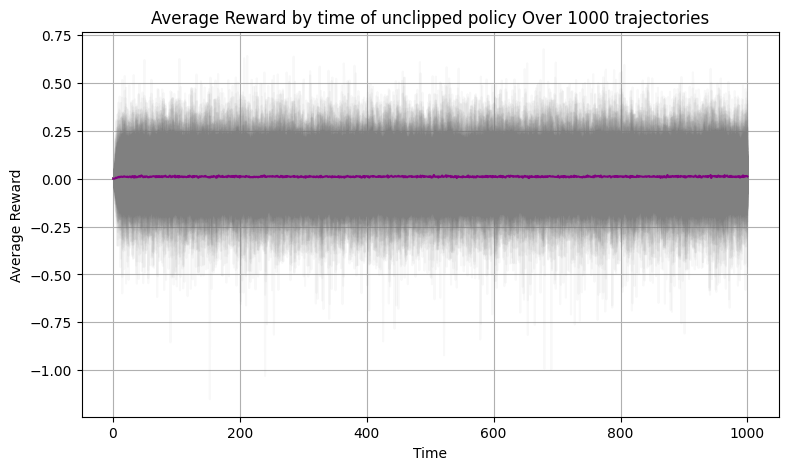

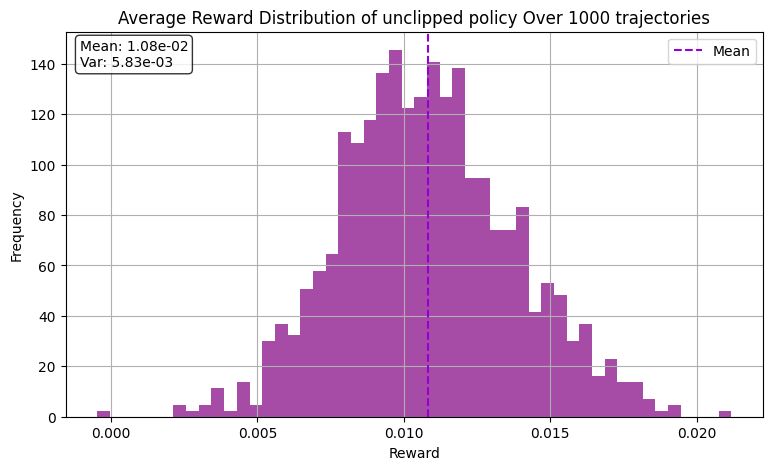

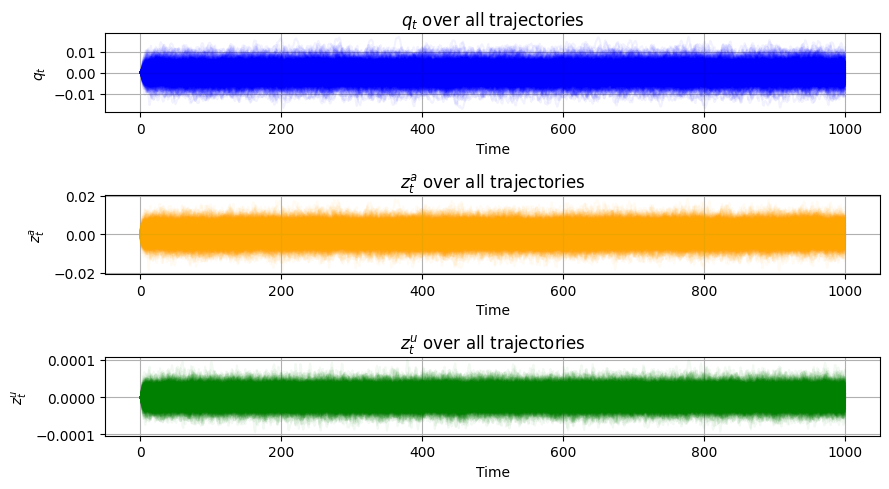

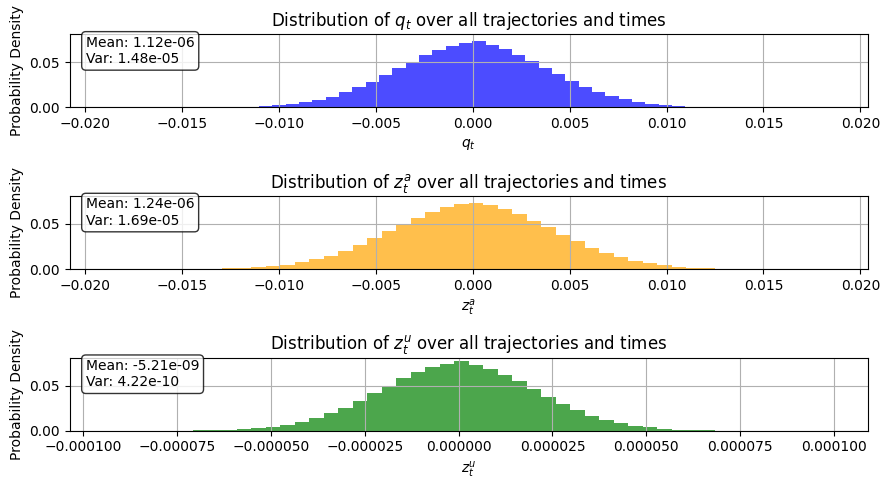

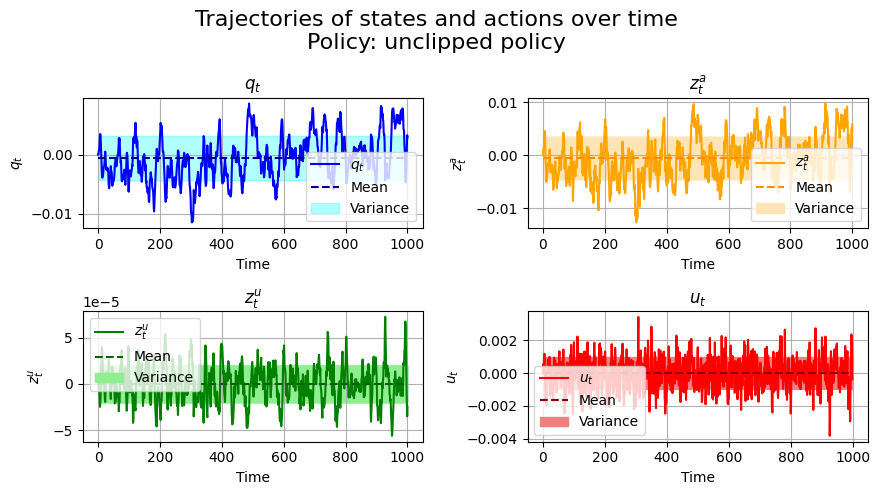

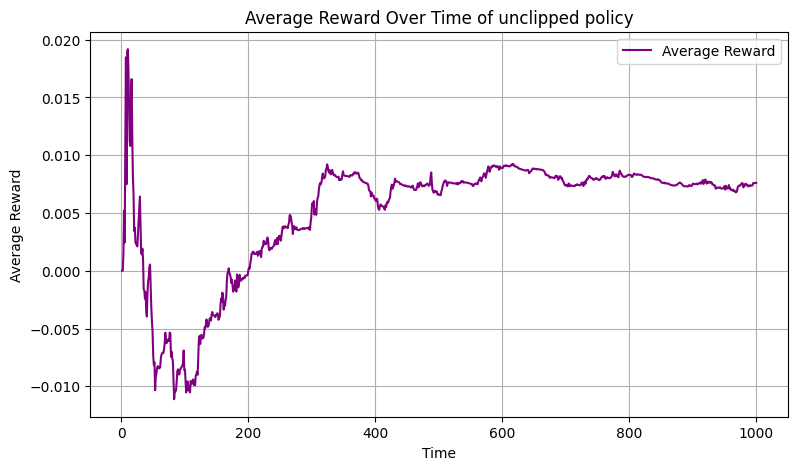

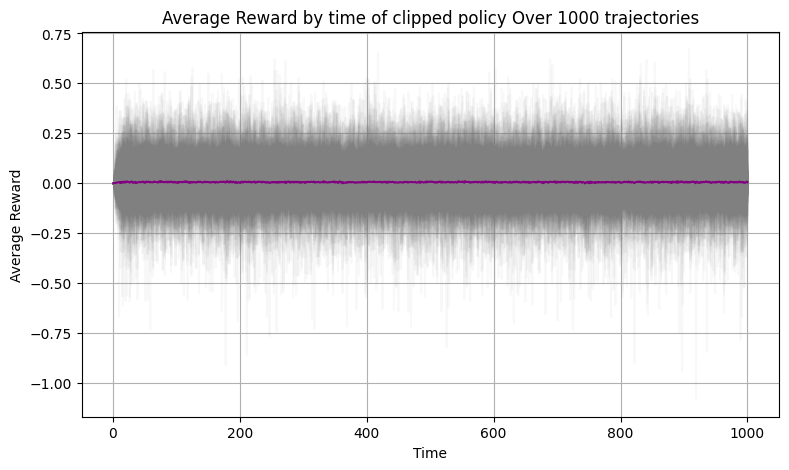

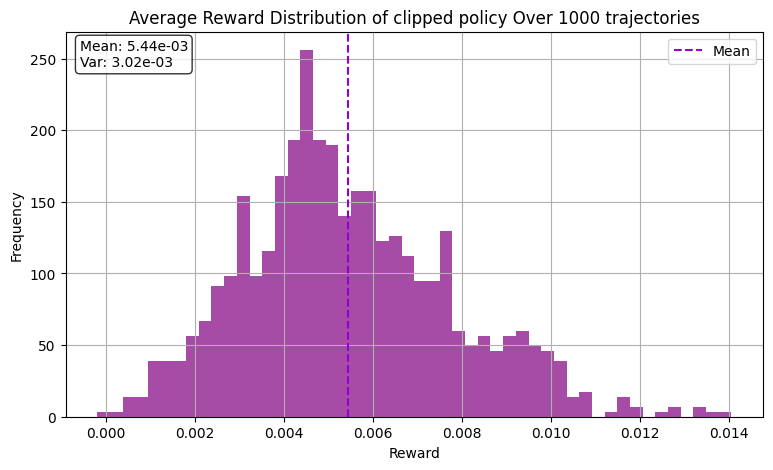

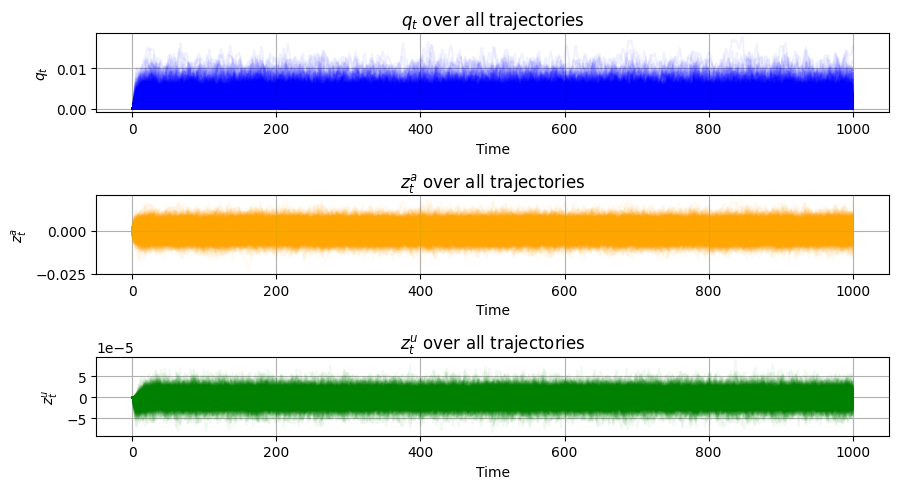

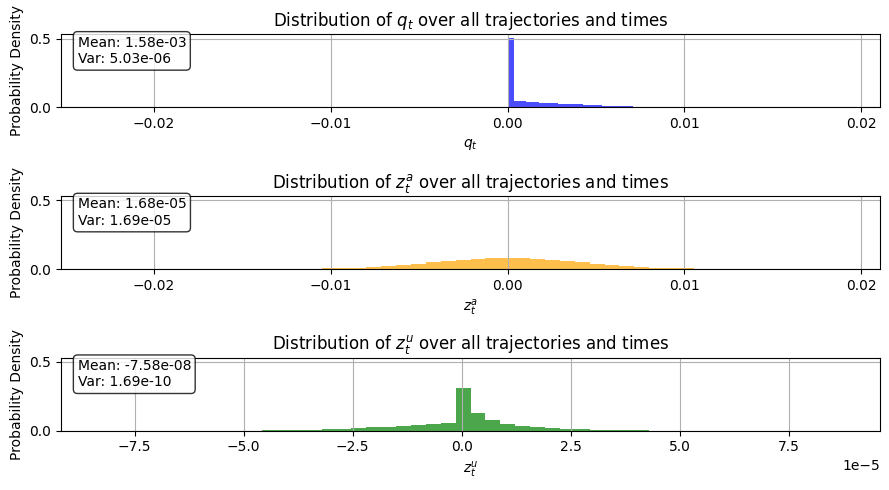

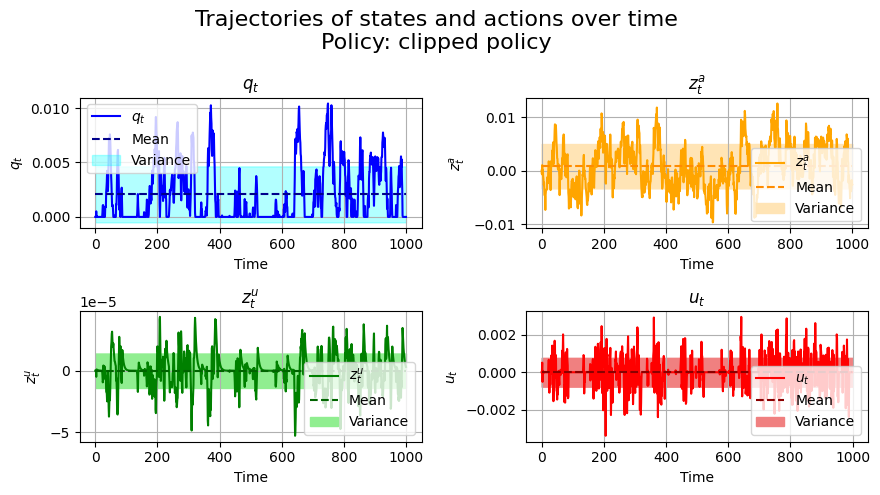

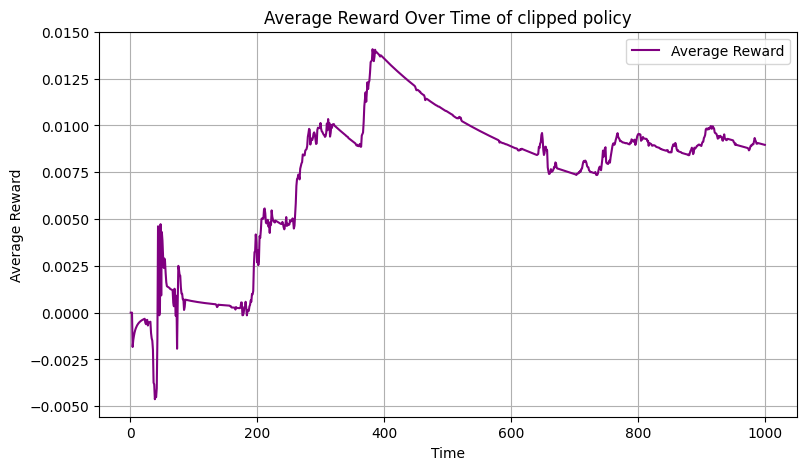

In [5]:
### simulate trajectories and plot the average reward over time
# Question 3.1.2

run_trajectories(policy, N=1000, name="unclipped policy", show_all=True)
run_trajectories(cliped_policy, N=1000, name="clipped policy", show_all=True)


### CMA

Average reward of best policy (CMA-ES) over 100 trajectories: 0.009327806232927066 and std: 0.13310278705300865


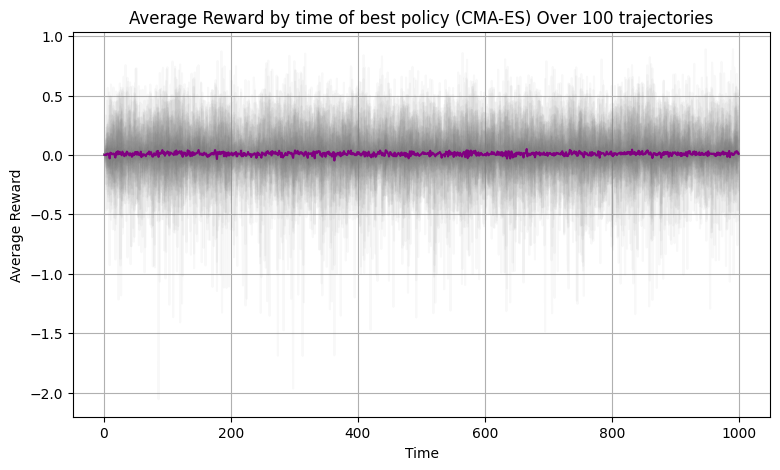

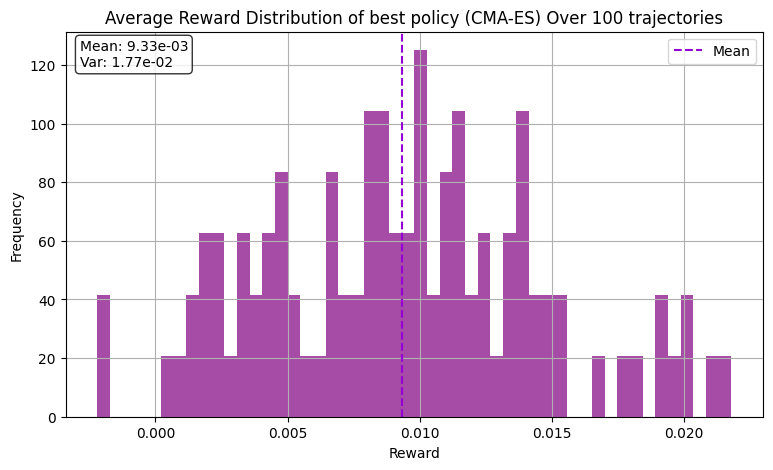

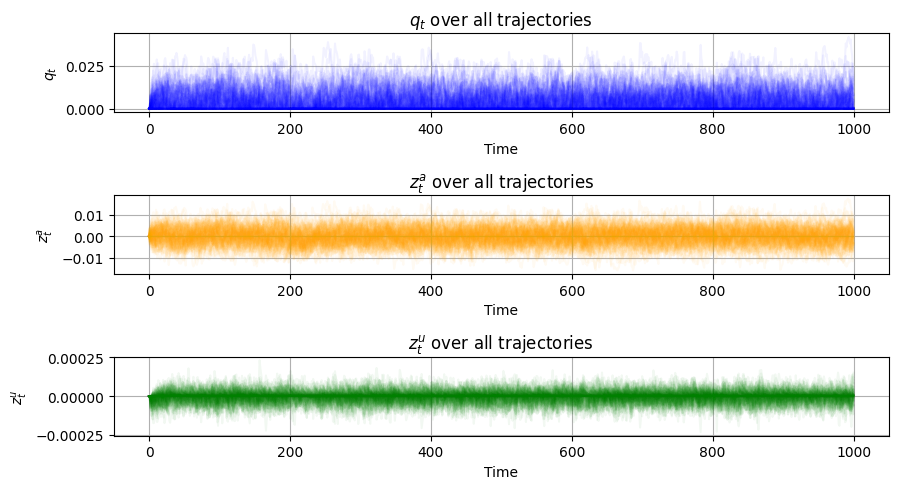

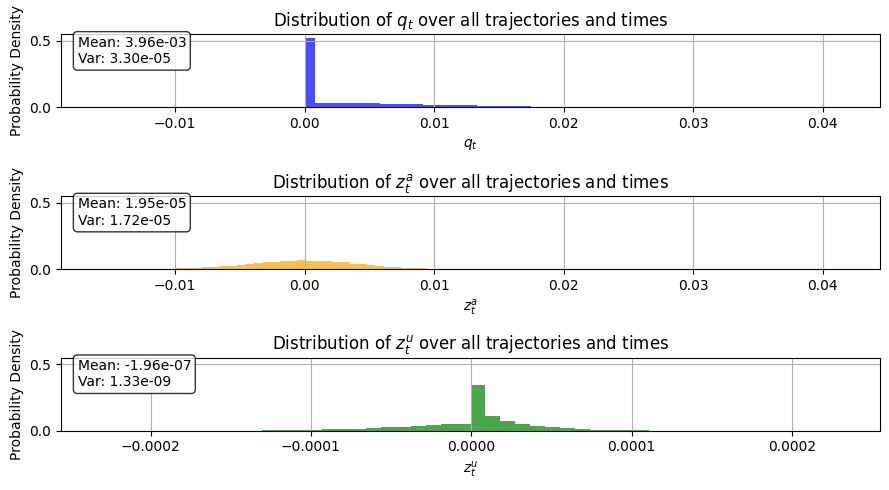

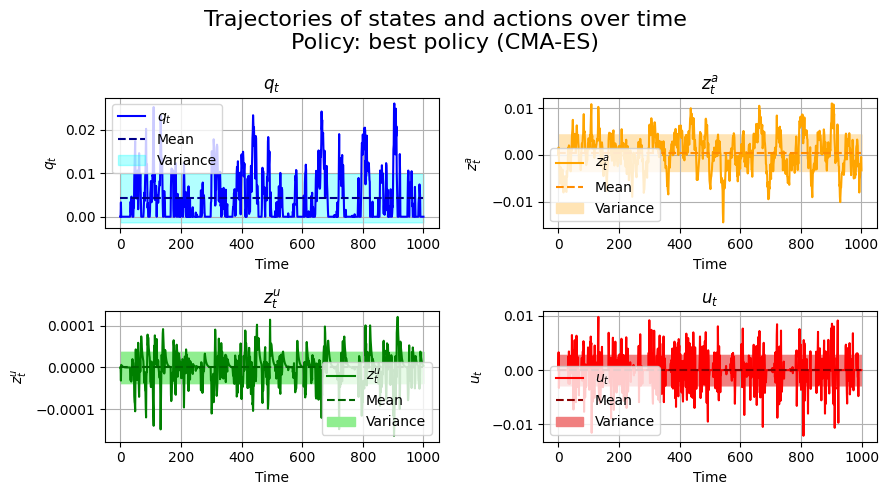

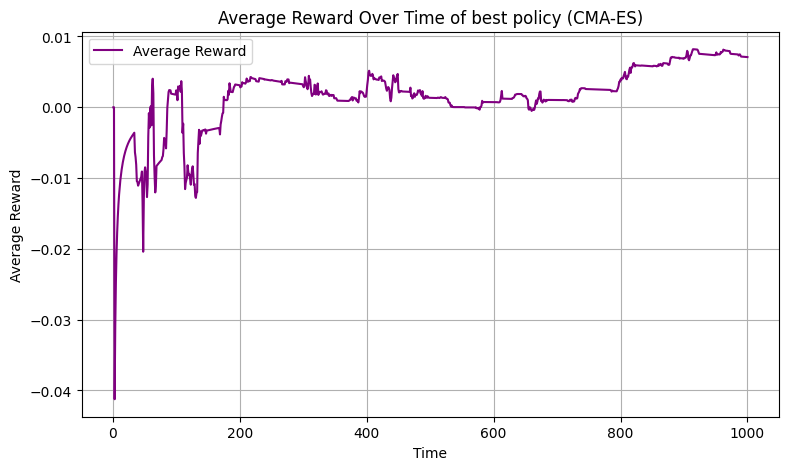

In [6]:
from best_policy import get_cma, get_cma_quadratic
best_params_cma, best_policy_cma = get_cma(recompute=False)
policy_list.append((best_policy_cma, "Best linear Policy (CMA-ES)"))
run_trajectories(best_policy_cma, N=100, name="best policy (CMA-ES)", show_all=True)
# best_params_cma_quadratic, best_policy_cma_quadratic = get_cma_quadratic(recompute=True)
# policy_list.append((best_policy_cma_quadratic, "Best quadratic Policy (CMA-ES)"))
# run_trajectories(best_policy_cma_quadratic, N=1000, name="best quadratic policy (CMA-ES)", show_all=True)

In [7]:

# x, u, xi_p = generate_trajectories(best_params_cma_quadratic, x0=(0, 0, 0), T=1000)
# plot_trajectories(x, u, xi_p, filename="question_3_1_1_clipped")
# plot_average_reward(x, u, xi_p, filename="question_3_1_1_clipped")

# Question 4.4 

In [8]:
#### SYSTEM MATRICES
# Define system matrices based on the problem description
F = np.array([[1, 0, 0], 
              [0, 1 - W_A, 0], 
              [0, 0, 1 - W_U]])

G = np.array([[1], 
              [0], 
              [W_U * BETA_U]])

D = np.array([[0, 0], [W_A * SIGMA_A, 0], [0, 0]])  # Disturbance matrix
  
# maximise r = 0.5 x.T Q x + 0.5 u.T R u + x.T N u
# minimise E(sum(-r))
# given    x_t+1 = F x_t + G u_t + D xi_t

Q = np.array([[-(1000 * SIGMA_P)**2, 1000, 1000], 
                     [1000, 0, 0], 
                     [1000, 0, 0]]) 

R = - (1000 * THETA * SIGMA_P)**2

P = np.array([[1000*GAMMA_U - THETA * ((1000 * SIGMA_P)**2)], 
                     [1000 * THETA], 
                     [1000 * THETA]]) 

# min c(x,u) = x.T Q x + u.T R u + 2 x.T S u
Q = -0.5 * Q
R = -0.5 * R
S = -0.5 * P

R = np.array([[R]], dtype=float)             # make it (1x1) PD


nu = 1  # number of inputs  = 1
nx = 3  # number of states  = 3
ny = 3  # number of outputs = 3

H = np.eye(ny)         # Output matrix (assuming full state observation)  # ny x nx
E = np.zeros((ny, 1))  # Direct feedthrough (assuming none)  # ny x nu

# we use F, G, Q, R, S from before
# min x.T Q x + u.T R u + 2 x.T S u
R_0 = Q # last stage cost  # nx x nx

model = (F, G, H, E, D, Q, R, S)


In [9]:
np.random.seed(42)

from lqr import compute_lqr_gain

K_lqr = compute_lqr_gain(model)

lqr_policy = lambda x: K_lqr @ x
lqr_clip_policy = lambda x: np.clip(lqr_policy(x), -x[0], 1 - x[0])

print("=" * 50)
# x, u, xi_p = generate_trajectories(lqr_policy, x0=(0, 0, 0), T=1000, N=1000)
# x, u, xi_p = generate_trajectories(lqr_clip_policy, x0=(0, 0, 0), T=1000, N=1000)


# x, u, xi_p = generate_trajectories(lqr_policy, x0=(0, 0, 0), T=1000, N=10, xi_p=np.zeros((1000, 10)))
# plot_average_reward(x, u, xi_p, filename="lqr_optimal_policy")
# plot_trajectories(x, u, xi_p, filename="lqr_optimal_policy")


# print(f"LQR Optimal Policy Average Reward: {average_reward(x, u, xi_p, 1000)}")
# # plot_trajectories(x, u, xi_p, T=1000)
# # plot_average_reward(x, u, xi_p, filename="lqr_optimal_policy")
run_trajectories(lqr_policy, N=100, T=1000, name="LQR Optimal Policy", show_all=True)
run_trajectories(lqr_clip_policy, N=100, T=1000, name="LQR Clip Policy", show_all=True)


policy_list.append((lqr_policy, "LQR Optimal Policy"))
policy_list.append((lqr_clip_policy, "LQR Clip Policy"))

K_lqr : [[-1.11182191  2.64863317  2.52792524]]  residual norm: 5.4606211020642276e-11
Stable: True
Average approximate reward J: 0.019355062306099072
Average reward of LQR Optimal Policy over 100 trajectories: 0.015998956126492016 and std: 0.19195658232778473
Average reward of LQR Clip Policy over 100 trajectories: 0.008675447339851572 and std: 0.13299133218139805
Error in callback <function flush_figures at 0x10f3c36a0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Generating trajectories: 100%|██████████| 10/10 [00:00<00:00, 59.62it/s]


Average reward of MPC Optimal Policy over 1 trajectories: -0.006371012785213839 and std: 0.0467330460050911


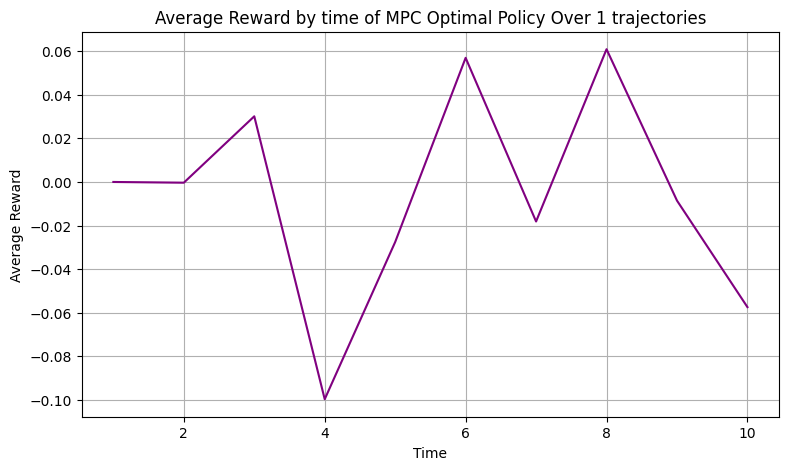

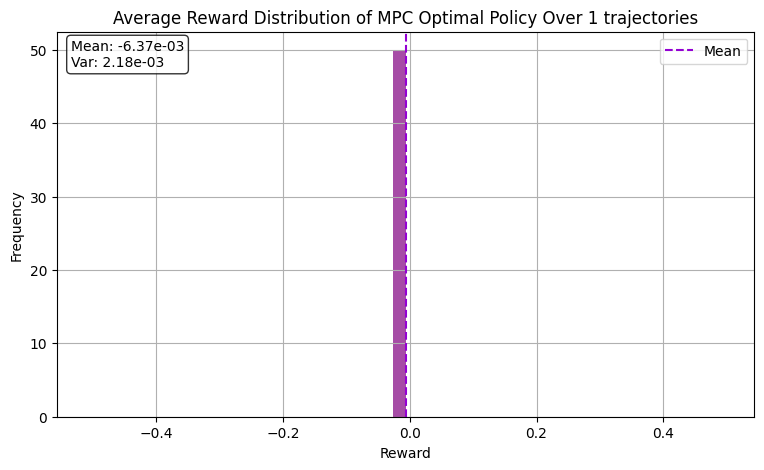

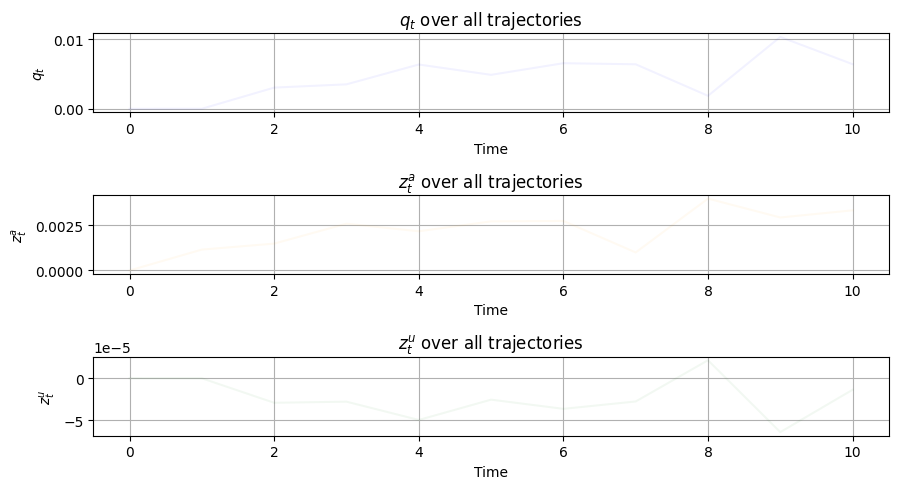

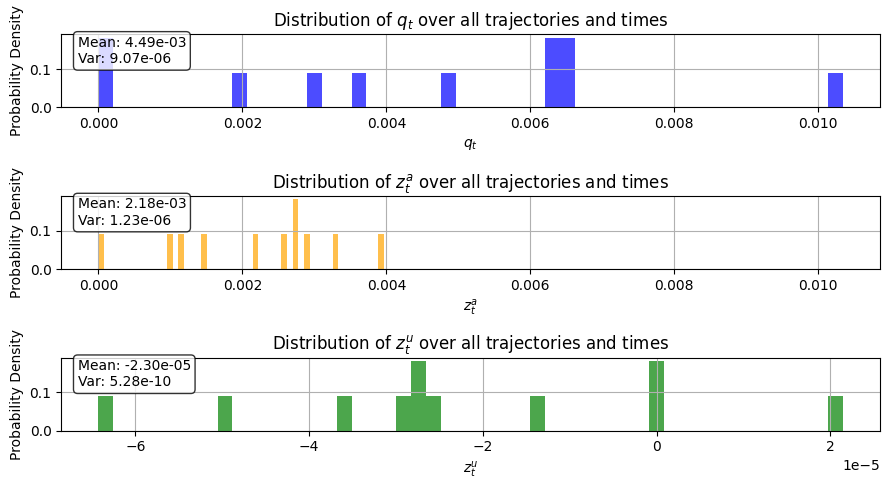

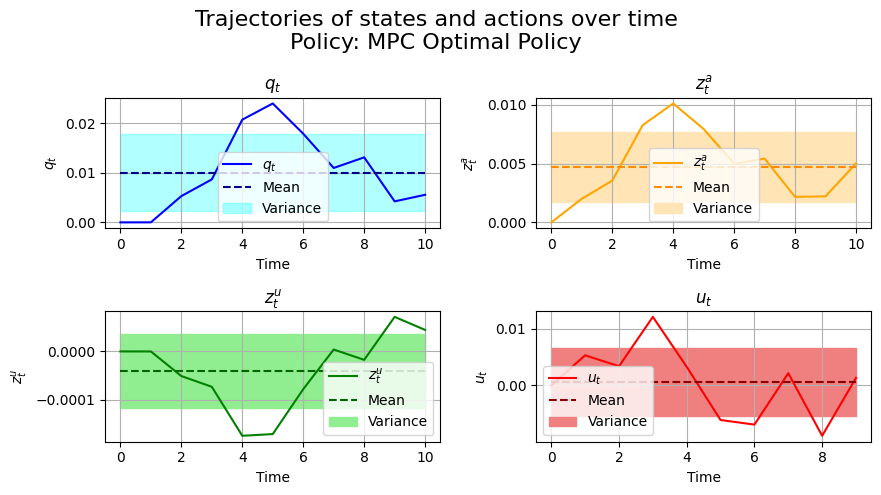

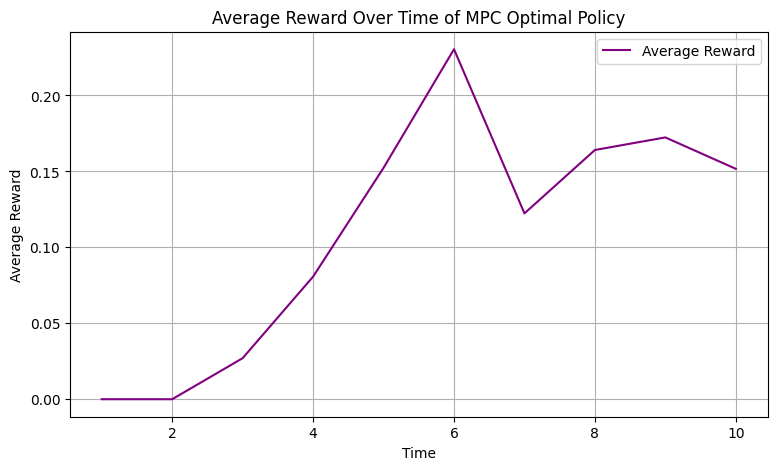

In [ ]:
from mpc import get_mpc_policy
from mpc_condensed import get_mpc_condensed_policy
import numpy as np
N = 10



u_min, u_max = [None], [None]  # scalar
y_min = np.array([0, None, None], dtype=object)  # (ny x 1)
y_max = np.array([1, None, None], dtype=object)   # (ny x 1)


mpc_policy = get_mpc_policy(N, model, y_min, y_max, u_min, u_max)
mpc_policy_condensed = get_mpc_condensed_policy(N, model, y_min, y_max, u_min, u_max)
# test
run_trajectories(mpc_policy, N=1, T=10, name="MPC Optimal Policy", show_all=True, show_progress=True)






Max difference between policies: 1.5998831999222696e-05
Mean difference between policies: 1.6320218205155012e-06


Generating trajectories: 100%|██████████| 1000/1000 [00:13<00:00, 75.99it/s]


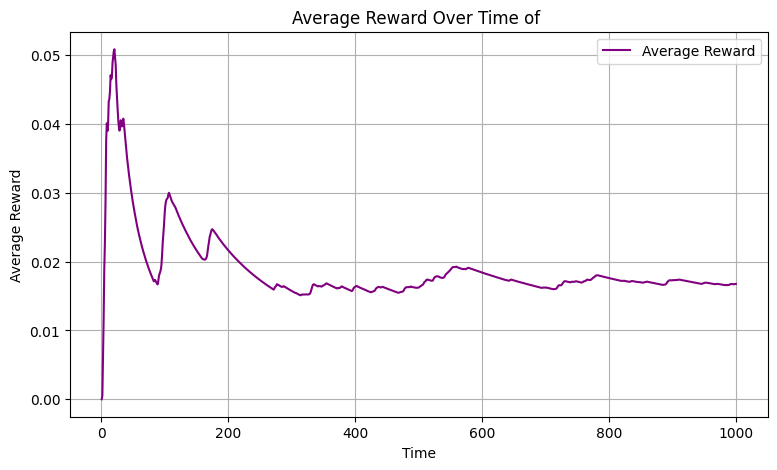

In [ ]:
### MPC



N = 10



compare_policies(mpc_policy, mpc_policy_condensed, N=100)
policy_list.append((mpc_policy_condensed, "MPC Optimal Policy"))

# takes 30 min to run
# run_trajectories(mpc_policy_condensed, N=1, T=1000, name="MPC Optimal Policy", show_all=True, show_progress=True)
# run_trajectories(mpc_policy_condensed, N=100, T=1000, name="MPC Optimal Policy", show_all=True, show_progress=True)

# interesting graph
x, u, xi_p = generate_trajectories(mpc_policy_condensed, x0=(0, 0, 0), T=1000, N=1, xi_p=np.zeros((1000, 10)), show_progress=True)
plot_average_reward(x, u, xi_p, filename="mpc_optimal_policy_without_noise")



    

Average reward of policy MPC Optimal Policy N=2 over 1 trajectories: 0.0014942158490329727 and std: 0.0046350410163148335
Average reward of policy MPC Optimal Policy N=3 over 1 trajectories: 0.0016423118477854315 and std: 0.004655796599960786
Average reward of policy MPC Optimal Policy N=4 over 1 trajectories: 0.0017025883459815428 and std: 0.004753246107232353
Average reward of policy MPC Optimal Policy N=5 over 1 trajectories: 0.0008792376041889958 and std: 0.004433517448521954
Average reward of policy MPC Optimal Policy N=6 over 1 trajectories: 0.0015095844576153547 and std: 0.0047125198194789926
Average reward of policy MPC Optimal Policy N=7 over 1 trajectories: 0.0015019835588822882 and std: 0.004755519975634185
Average reward of policy MPC Optimal Policy N=8 over 1 trajectories: 0.0015013432683902122 and std: 0.004752400209809638
Average reward of policy MPC Optimal Policy N=9 over 1 trajectories: 0.0015115540104247362 and std: 0.004741540296856848
Average reward of policy MPC O

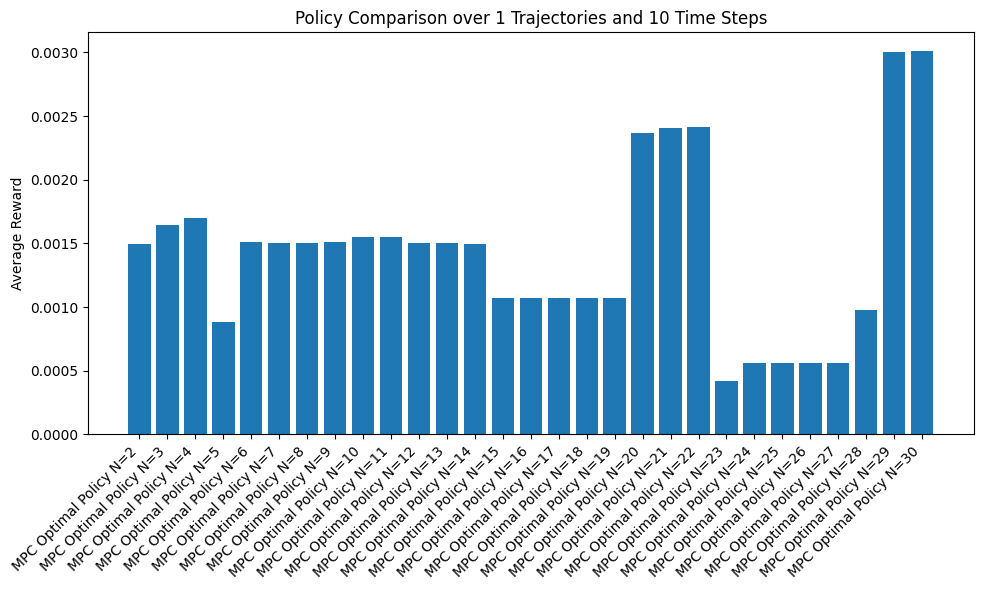

In [ ]:

def compare_policies(po_lst, N=1, T=1000):
    # generate random xi
    xi_p = np.random.normal(0, 1, (T, N))
    xi_a = np.random.normal(0, SIGMA_A, (T, N))
    rewards, stds = [], []
    for pol in po_lst:
        policy, name = pol
        all_x, all_u, all_xi_p = generate_trajectories(policy, x0=(0, 0, 0), T=T, N=N, xi_p=xi_p, xi_a=xi_a)
        all_rewards = reward(all_x, all_u, all_xi_p, T).T
        reward_value = np.nanmean(all_rewards)
        reward_std = np.nanstd(all_rewards)
        print(f"Average reward of policy {name} over {N} trajectories: {reward_value} and std: {reward_std}")
        rewards.append(reward_value)
        stds.append(reward_std)
    
    # plot bar chart of rewards with error bars
    plt.figure(figsize=(10, 6))
    plt.bar([name for _, name in po_lst], rewards, capsize=5)
    plt.ylabel("Average Reward")
    plt.title(f"Policy Comparison over {N} Trajectories and {T} Time Steps")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("policy_comparison.png")

compare_policies([(get_mpc_condensed_policy(i, model, y_min, y_max, u_min, u_max)
                   , f"MPC Optimal Policy N={i}") for i in range(2, 31)], N=1, T=10)


In [ ]:
#### graphs of N vs reward
#### too much variance
# Ns = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30]
# rewards = []
# for N in Ns:
#     pol = get_mpc_condensed_policy(N)
#     x, u, xi_p = generate_trajectories(pol, x0=(0, 0, 0), T=1000, N=1, show_progress=True)
#     rewards_N = c(g(x[0, :, :], x[1, :, :], x[2, :, :], u[0, :])).T
#     plt.plot(N * np.ones_like(rewards_N), rewards_N, 'o', alpha=0.3, label=f"N={N}" if N==Ns[0] else "")
#     rewards.append(np.mean(rewards_N))
#     print(f"N={N}, Average reward: {np.mean(rewards_N)}, std: {np.std(rewards_N)}")

# plt.figure()
# plt.plot(Ns, rewards, marker='o')
# plt.xlabel('MPC Horizon N')
# plt.ylabel('Average Reward')
# plt.title('Average Reward vs MPC Horizon')
# plt.grid()
# plt.savefig("figures/mpc_horizon_vs_reward.svg", format='svg')

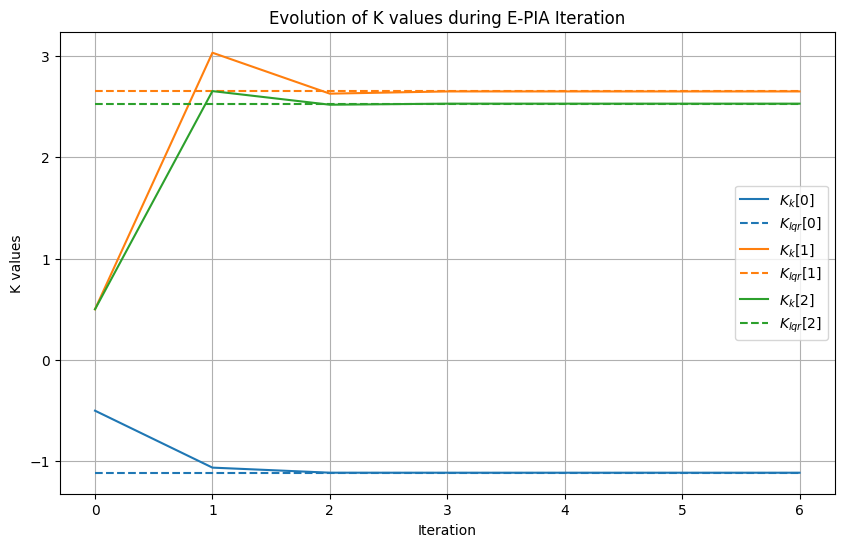

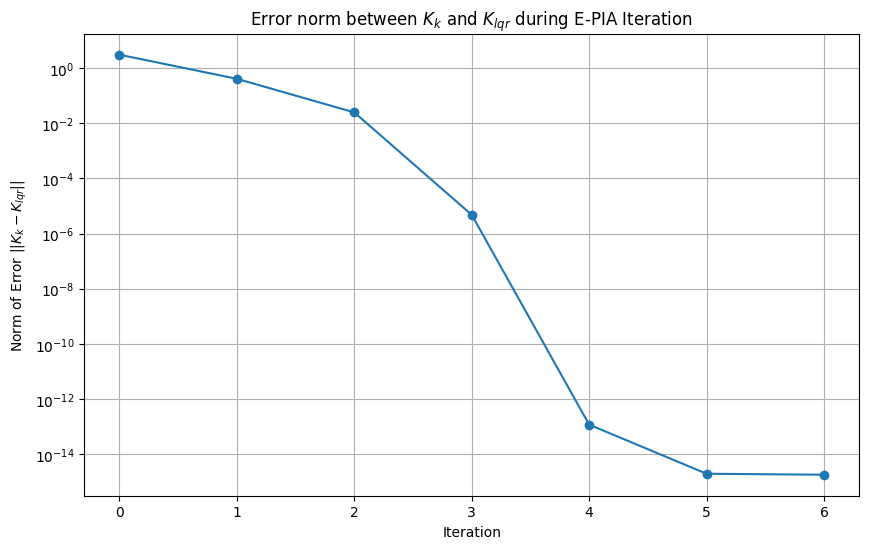

In [ ]:
### plot K_list
from e_pia import compute_E_PIA
K_list = compute_E_PIA(model, max_iterations=1000, tolerance=1e-15, K_init=[-0.5, 0.5, 0.5])

K_array = np.vstack(K_list).squeeze()  # shape (num_iterations, 3)
plt.figure(figsize=(10, 6))
for i in range(K_array.shape[1]):
    plt.plot(K_array[:, i], label='$K_k' + f'[{i}]$')
    plt.hlines(K_lqr[0, i], 0, len(K_array)-1, linestyles='dashed', label="$K_{lqr}" +f"[{i}]$", colors='C'+str(i))

plt.xlabel('Iteration')
plt.ylabel('K values')
plt.title('Evolution of K values during E-PIA Iteration')
plt.legend()
plt.grid()
plt.savefig("figures/EPIA_K_values.svg", format='svg')



## Plot the evolution of the error norm between Kk and Klqr
# K_lqr = K_opt
error_norms = [np.linalg.norm(K - K_lqr) for K in K_list]
plt.figure(figsize=(10, 6))
plt.semilogy(error_norms, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Norm of Error $||K_k - K_{lqr}||$')
plt.title('Error norm between $K_k$ and $K_{lqr}$ during E-PIA Iteration')
plt.grid()
plt.savefig("figures/EPIA_convergence.svg", format='svg')

In [ ]:
from Q_lambda import q_lambda_learning_LQR
K_learned, H, Q_list = q_lambda_learning_LQR(model, lambda_=0.9, alpha=1e-3, n_iter=50000)

print("Learned K:", K_learned)
print("LQR K:", K_lqr)


/Users/aymeric/Projets/Q7-M1/Stocha/linma2222-project/part3/Q_lambda.py:65: RuntimeWarning: overflow encountered in matmul
  Q_now = float(theta @ psi_now)
/Users/aymeric/Projets/Q7-M1/Stocha/linma2222-project/part3/Q_lambda.py:66: RuntimeWarning: overflow encountered in matmul
  Q_next = float(theta @ psi_next)


Learned K: [[nan nan nan]]
LQR K: [[-1.11182191  2.64863317  2.52792524]]


Evaluation of all policies over 1000 trajectories ...


Generating trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 70412.03it/s]


Initial Policy                  Average reward = 0.01069307 , Std = 0.00298523


Generating trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 52881.60it/s]


Clipped Initial Policy          Average reward = 0.00531608 , Std = 0.00233415


...

LQR Optimal Policy              Average reward = 0.01653793 , Std = 0.00683619


Generating trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 63266.32it/s]


LQR Clip Policy                 Average reward = 0.00829242 , Std = 0.00491096


Generating trajectories: 100%|██████████| 1000/1000 [00:12<00:00, 82.44it/s]


MPC Optimal Policy              Average reward = 0.00354931 , Std = 0.00000000


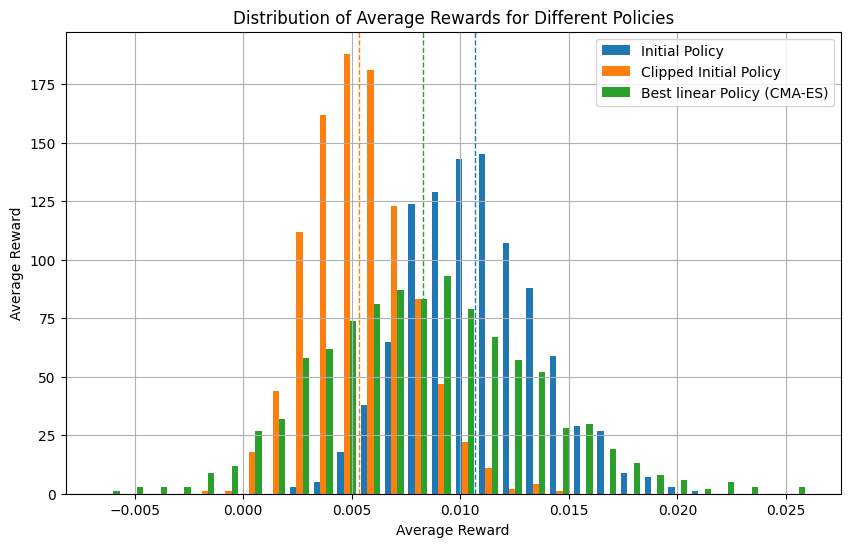

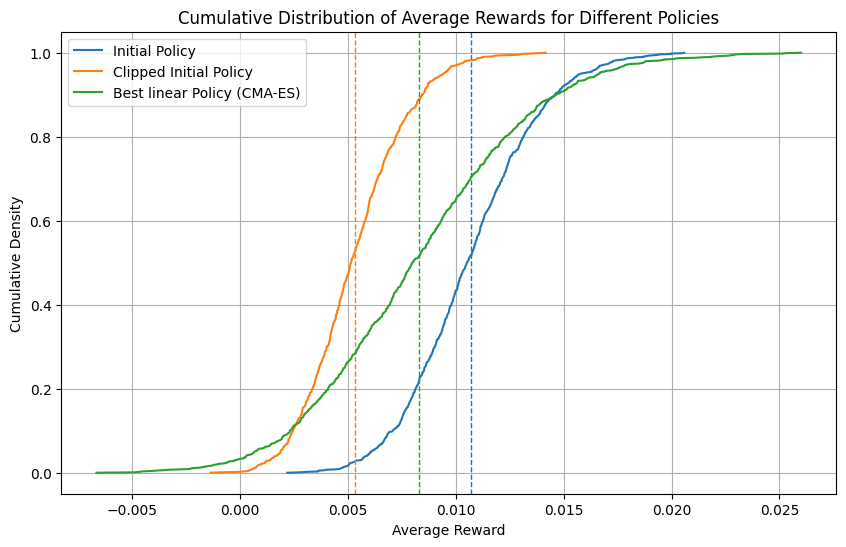

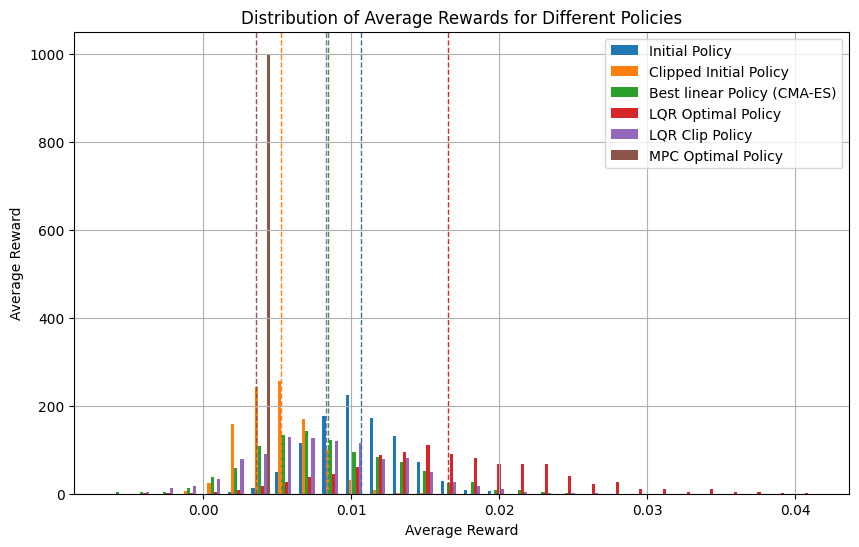

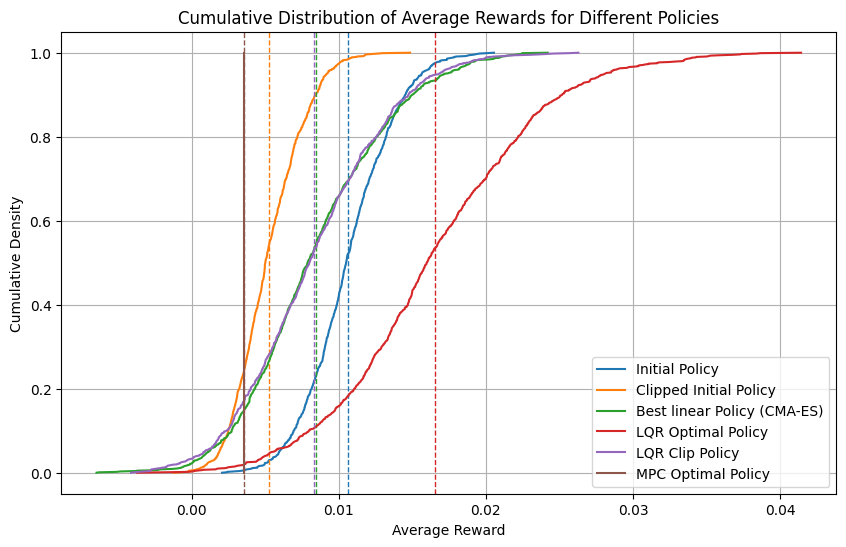

In [ ]:
# run for all 3 policies and store the rewards
import matplotlib.pyplot as plt
import numpy as np

# filter out duplicate policies by name
policy_list = list({name: (func, name) for func, name in policy_list}.values())


def plot_reward_distribution(policy_list, name="", n_traj=1000):
    print(f"Evaluation of all policies over {n_traj} trajectories ...")

    all_rewards = np.zeros((len(policy_list), n_traj))
    for i in range(len(policy_list)):
        x, u, xi_p = generate_trajectories(policy_list[i][0], x0=(0, 0, 0), T=1000, N=n_traj if "mpc" not in policy_list[i][1].lower() else 1, show_progress=True)
        all_rewards[i] = np.nanmean(reward(x, u, xi_p, 1000), axis=0).T
        print(f"{policy_list[i][1]:30s}  Average reward = {np.nanmean(all_rewards[i]):.8f} , Std = {np.std(all_rewards[i]):.8f}")


    # plot all the rewards
    plt.figure(figsize=(10, 6))
    labels = [policy_list[i][1] for i in range(len(policy_list))]
    plt.hist(all_rewards.T, bins=30, label=labels, alpha=1)
    # add the mean of each distribution
    for i in range(all_rewards.shape[0]):
        plt.axvline(np.nanmean(all_rewards[i]), color=f'C{i}', linestyle='dashed', linewidth=1)
    plt.xlabel('Average Reward')

    plt.title('Distribution of Average Rewards for Different Policies')
    plt.ylabel('Average Reward')
    plt.grid()
    plt.legend()
    plt.savefig(f"figures/policy_comparison_histogram_{name}.svg", format='svg')


    # the integral plot
    plt.figure(figsize=(10, 6))
    for i in range(all_rewards.shape[0]):
        sorted_rewards = np.sort(all_rewards[i])
        cumulative = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)
        plt.plot(sorted_rewards, cumulative, label=labels[i])
        plt.axvline(np.nanmean(all_rewards[i]), color=f'C{i}', linestyle='dashed', linewidth=1)

    plt.xlabel('Average Reward')
    plt.title('Cumulative Distribution of Average Rewards for Different Policies')
    plt.ylabel('Cumulative Density')
    plt.grid()
    plt.legend()
    plt.savefig(f"figures/policy_comparison_cumulative_distribution_{name}.svg", format='svg')


plot_reward_distribution(policy_list[:3], name="first_three", n_traj=1000)
plot_reward_distribution(policy_list, name="all", n_traj=1000)


In [ ]:
plt.show()
